# Suicide Rates project. Reproducible Resarch
Replicating the key analyses taken from [lmorgan95's R notebook](https://www.kaggle.com/code/lmorgan95/r-suicide-rates-in-depth-stats-insights/report)— translated to Python, with addition of modelling.

Team Members:

- Lukasz Brzoska | 472892
- Mustafa Kaan Koç | 476456
- Yılmaz Can Ekmekçi | 473105

## 1. Setup & Data Overview

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'font.family': 'DejaVu Sans',
})
PALETTE = sns.color_palette('Set2')
SEX_COLORS = {'male': '#4C72B0', 'female': '#DD8452'}

AGE_ORDER = ['5-14 years', '15-24 years', '25-34 years',
             '35-54 years', '55-74 years', '75+ years']
GEN_ORDER  = ['G.I. Generation', 'Silent', 'Boomers',
              'Generation X', 'Millenials', 'Generation Z']

In [48]:
df = pd.read_csv("data\\master.csv")

# ── Clean column names ─────────────────────────────────────────────────────
df.columns = df.columns.str.strip()
df = df.rename(columns={
    'suicides/100k pop': 'suicides_per_100k',
    'HDI for year':      'hdi',
    'gdp_for_year ($)':  'gdp_total',
    'gdp_per_capita ($)':'gdp_per_capita',
    'country-year':      'country_year',
})

# ── Tidy types ─────────────────────────────────────────────────────────────
df['gdp_total'] = df['gdp_total'].str.replace(',', '').astype(float)
df['age']       = pd.Categorical(df['age'],       categories=AGE_ORDER,  ordered=True)
df['generation']= pd.Categorical(df['generation'],categories=GEN_ORDER,  ordered=True)

print(f"Shape : {df.shape}")
print(f"Years : {df['year'].min()} – {df['year'].max()}")
print(f"Countries: {df['country'].nunique()}")
df.head()

Shape : (27820, 12)
Years : 1985 – 2016
Countries: 101


,country,year,sex,age,suicides_no,population,suicides_per_100k,country_year,hdi,gdp_total,gdp_per_capita,generation
0,Albania,1987,male,15-24 years,21,312900,6.71,Albania1987,NaN,2.156625e+09,796,Generation X
1,Albania,1987,male,35-54 years,16,308000,5.19,Albania1987,NaN,2.156625e+09,796,Silent
2,Albania,1987,female,15-24 years,14,289700,4.83,Albania1987,NaN,2.156625e+09,796,Generation X
3,Albania,1987,male,75+ years,1,21800,4.59,Albania1987,NaN,2.156625e+09,796,G.I. Generation
4,Albania,1987,male,25-34 years,9,274300,3.28,Albania1987,NaN,2.156625e+09,796,Boomers


In [49]:
# Missing values 
missing = df.isnull().sum()
missing[missing > 0]

hdi    19456
dtype: int64

In [50]:
# Basic descriptive stats 
df[['suicides_no', 'population', 'suicides_per_100k', 'gdp_per_capita']].describe().round(2)

,suicides_no,population,suicides_per_100k,gdp_per_capita
count,27820.00,27820.00,27820.00,27820.00
mean,242.57,1844793.62,12.82,16866.46
std,902.05,3911779.44,18.96,18887.58
min,0.00,278.00,0.00,251.00
25%,3.00,97498.50,0.92,3447.00
50%,25.00,430150.00,5.99,9372.00
75%,131.00,1486143.25,16.62,24874.00
max,22338.00,43805214.00,224.97,126352.00


## 2. Global Trend Over Time
Aggregate suicides per 100k population for each year across all countries.

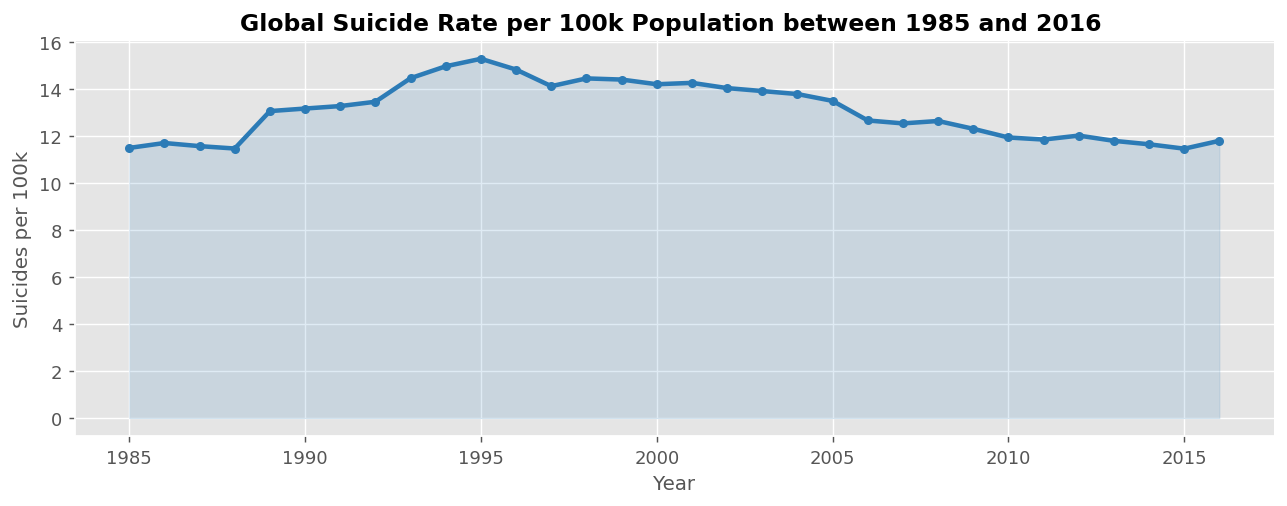

In [51]:
global_year = (
    df.groupby('year')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(global_year['year'], global_year['rate'],
        color='#2c7bb6', linewidth=2.5, marker='o', markersize=4)
ax.fill_between(global_year['year'], global_year['rate'],
                alpha=0.15, color='#2c7bb6')
ax.set(title='Global Suicide Rate per 100k Population between 1985 and 2016 ',
       xlabel='Year', ylabel='Suicides per 100k')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

Interpretatin: The global suicide rate rose sharply from the late 1980s, peaked around 1995 at approximately 15 per 100k, then steadily declined over the following two decades to reach its lowest point near 11.5 per 100k by 2015–2016.

In [52]:
! pip install pycountry_convert


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 3. Global Suicide by Continent

In [53]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        country_alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(country_alpha2)

        continent_map = {
            "AF": "Africa",
            "AS": "Asia",
            "EU": "Europe",
            "NA": "Americas",
            "SA": "Americas",
            "OC": "Oceania"
        }

        return continent_map.get(continent_code)

    except:
        return None

df["continent"] = df["country"].apply(country_to_continent)

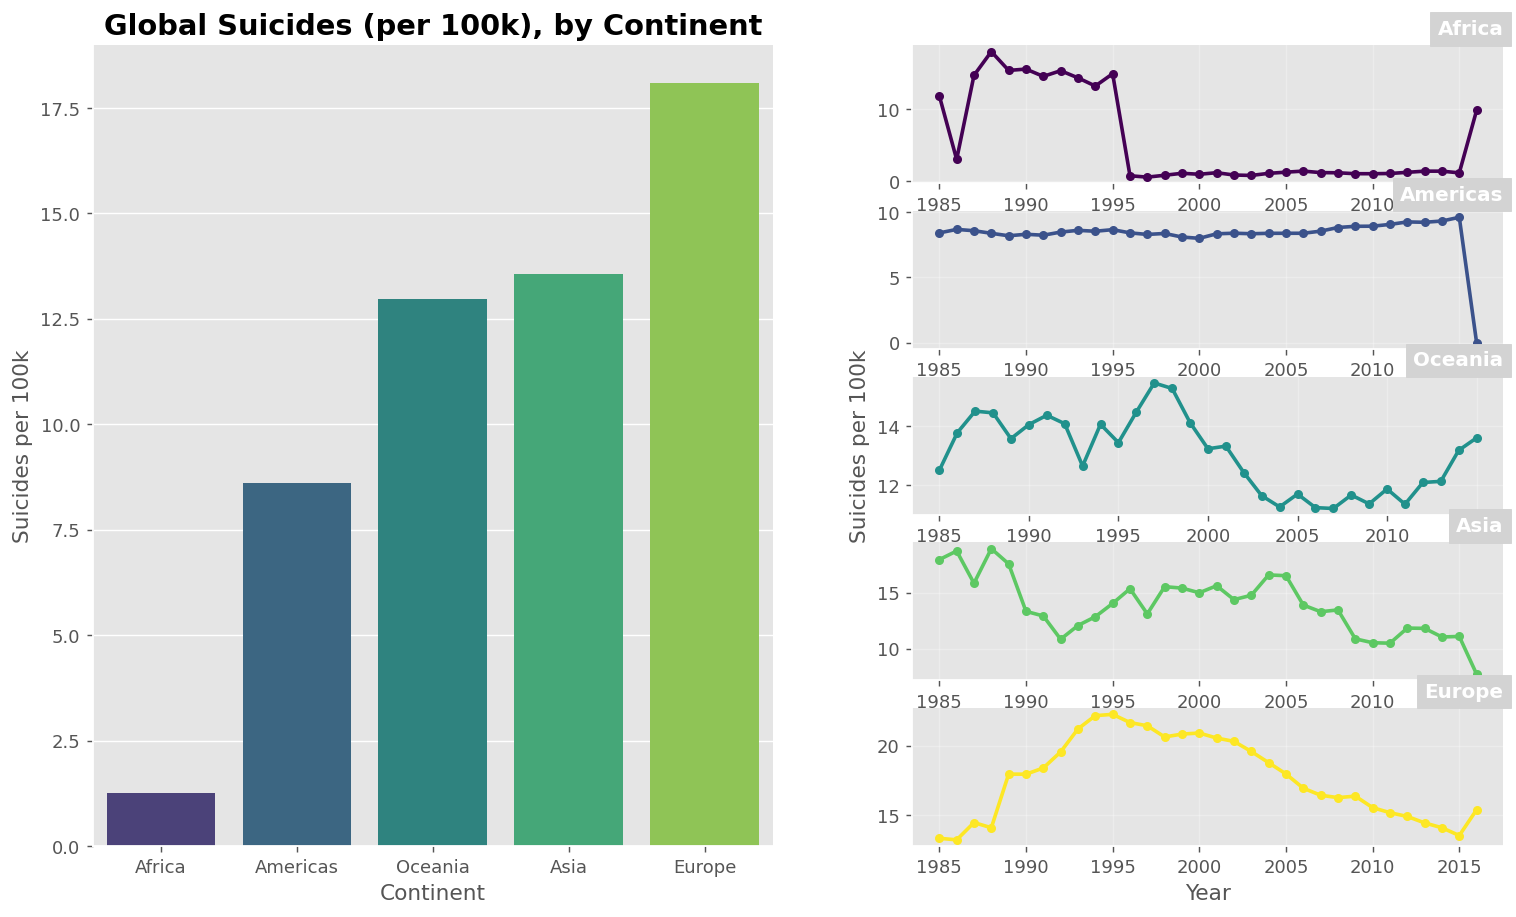

In [55]:
plt.style.use("ggplot")

# CONTINENT SUMMARY

continent_summary = (
    df.groupby("continent")
      .agg(
          suicides=("suicides_no", "sum"),
          population=("population", "sum")
      )
      .reset_index()
)

continent_summary["rate"] = (
    continent_summary["suicides"]
    /
    continent_summary["population"]
) * 100000

continent_order = [
    "Africa",
    "Americas",
    "Oceania",
    "Asia",
    "Europe"
]

continent_summary["continent"] = pd.Categorical(
    continent_summary["continent"],
    categories=continent_order,
    ordered=True
)

continent_summary = continent_summary.sort_values(
    "continent"
)

# YEARLY CONTINENT TRENDS

continent_year = (
    df.groupby(["continent", "year"])
      .agg(
          suicides=("suicides_no", "sum"),
          population=("population", "sum")
      )
      .reset_index()
)

continent_year["rate"] = (
    continent_year["suicides"]
    /
    continent_year["population"]
) * 100000

continent_year["continent"] = pd.Categorical(
    continent_year["continent"],
    categories=continent_order,
    ordered=True
)

# PLOT

fig = plt.figure(figsize=(14,8))

gs = fig.add_gridspec(
    nrows=5,
    ncols=2,
    width_ratios=[1.15, 1],
    wspace=0.22
)

# LEFT: BAR CHART

ax0 = fig.add_subplot(gs[:, 0])

palette = sns.color_palette("viridis", 5)

sns.barplot(
    data=continent_summary,
    x="continent",
    y="rate",
    palette=palette,
    ax=ax0
)

ax0.set_title(
    "Global Suicides (per 100k), by Continent",
    fontsize=16
)

ax0.set_xlabel("Continent")
ax0.set_ylabel("Suicides per 100k")

# RIGHT: FACETED LINE CHARTS

facet_colors = {
    "Africa": "#440154",
    "Americas": "#3B528B",
    "Oceania": "#21918C",
    "Asia": "#5DC863",
    "Europe": "#FDE725"
}

for i, continent in enumerate(continent_order):

    ax = fig.add_subplot(gs[i, 1])

    temp = continent_year[
        continent_year["continent"] == continent
    ]

    ax.plot(
        temp["year"],
        temp["rate"],
        marker="o",
        linewidth=2,
        markersize=4,
        color=facet_colors[continent]
    )

    ax.set_title(
        continent,
        loc="right",
        fontsize=11,
        backgroundcolor="lightgray",
        color="white"
    )

    ax.grid(True, alpha=0.3)

    if i < 4:
        ax.set_xlabel("")

    else:
        ax.set_xlabel("Year")

    if i == 2:
        ax.set_ylabel("Suicides per 100k")

# OVERALL TITLES

fig.text(
    0.08,
    0.96,
    "",
    fontsize=22
)

fig.text(
    0.63,
    0.82,
    "",
    fontsize=16
)

plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

# finish

Europe has consistently had the highest suicide rate among all continents at around 18 per 100k, though it has seen a notable decline since its peak in the mid-1990s, while Africa remains the lowest throughout the entire period.

## 4. AGE DIFFERENCES BY CONTINENT

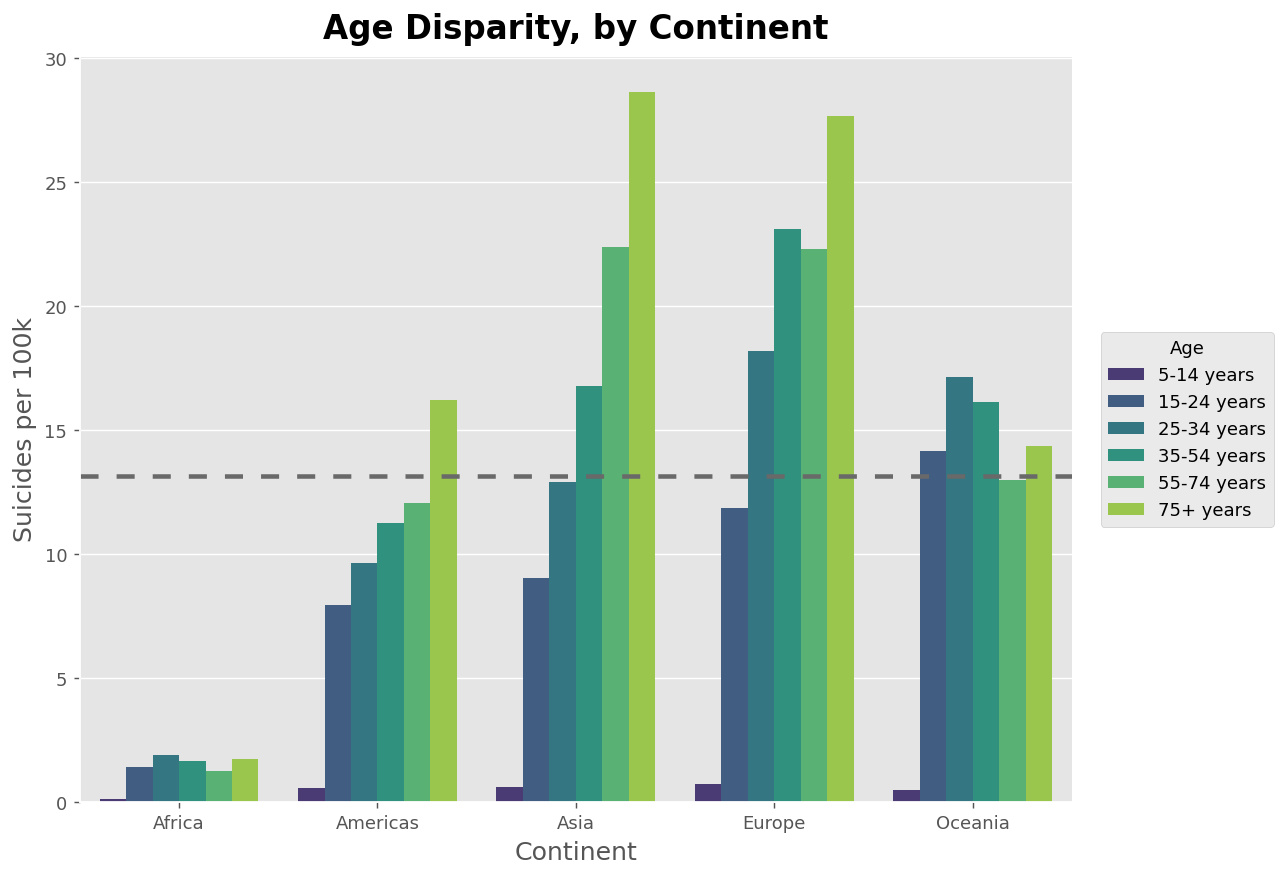

In [57]:

continent_age = (
    df.groupby(["continent", "age"])
      .agg(
          suicides=("suicides_no", "sum"),
          population=("population", "sum")
      )
      .reset_index()
)

continent_age["rate"] = (
    continent_age["suicides"]
    / continent_age["population"]
) * 100000

continent_order = [
    "Africa",
    "Americas",
    "Asia",
    "Europe",
    "Oceania"
]

age_order = [
    "5-14 years",
    "15-24 years",
    "25-34 years",
    "35-54 years",
    "55-74 years",
    "75+ years"
]

continent_age["continent"] = pd.Categorical(
    continent_age["continent"],
    categories=continent_order,
    ordered=True
)

continent_age["age"] = pd.Categorical(
    continent_age["age"],
    categories=age_order,
    ordered=True
)

continent_age = continent_age.sort_values(
    ["continent", "age"]
)

plt.style.use("ggplot")

fig, ax = plt.subplots(figsize=(10, 7))

sns.barplot(
    data=continent_age,
    x="continent",
    y="rate",
    hue="age",
    palette="viridis",
    ax=ax
)

# Global average line
global_rate = (
    df["suicides_no"].sum()
    /
    df["population"].sum()
) * 100000

ax.axhline(
    global_rate,
    color="dimgray",
    linestyle=(0, (4, 4)),
    linewidth=2.5
)

ax.set_title(
    "Age Disparity, by Continent",
    fontsize=18,
    pad=10
)

ax.set_xlabel("Continent", fontsize=14)
ax.set_ylabel("Suicides per 100k", fontsize=14)

ax.legend(
    title="Age",
    bbox_to_anchor=(1.02, 0.5),
    loc="center left"
)

plt.suptitle(
    "",
    x=0.02,
    y=1.02,
    ha="left",
    fontsize=22
)

plt.tight_layout()
plt.show()

Across all continents, suicide rates rise sharply with age — the 75+ group consistently shows the highest rates — with Asia and Europe standing out as the most affected regions, particularly among older adults.

## 5. By Sex
Compare male vs female suicide rates across every year.

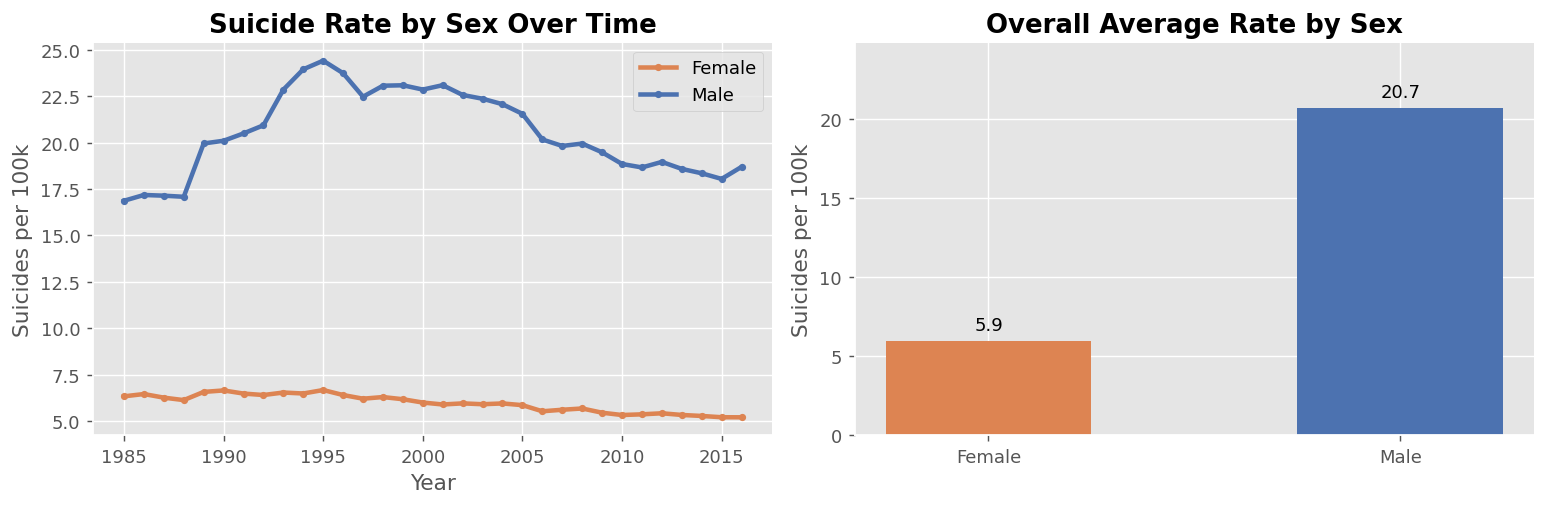

Male-to-female ratio: 3.5×


In [58]:
sex_year = (
    df.groupby(['year', 'sex'])
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Line chart ─────────────────────────────────────────────────────────────
for sex, grp in sex_year.groupby('sex'):
    axes[0].plot(grp['year'], grp['rate'],
                 label=sex.capitalize(), color=SEX_COLORS[sex],
                 linewidth=2.5, marker='o', markersize=3)
axes[0].set(title='Suicide Rate by Sex Over Time',
            xlabel='Year', ylabel='Suicides per 100k')
axes[0].legend()

# ── Overall bar ────────────────────────────────────────────────────────────
sex_total = (
    df.groupby('sex')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)
bars = axes[1].bar(sex_total['sex'].str.capitalize(),
                   sex_total['rate'],
                   color=[SEX_COLORS[s] for s in sex_total['sex']], width=0.5)
axes[1].bar_label(bars, fmt='%.1f', padding=4, fontsize=10)
axes[1].set(title='Overall Average Rate by Sex',
            ylabel='Suicides per 100k', ylim=(0, sex_total['rate'].max()*1.2))

plt.tight_layout()
plt.show()

ratio = sex_total.set_index('sex')['rate']
print(f"Male-to-female ratio: {ratio['male']/ratio['female']:.1f}×")

Males have a suicide rate roughly 3.5 times higher than females (20.7 vs 5.9 per 100k), and while the male rate peaked around 1995 and has since declined, the female rate has remained remarkably flat throughout the entire period.

## 6. By Age Group

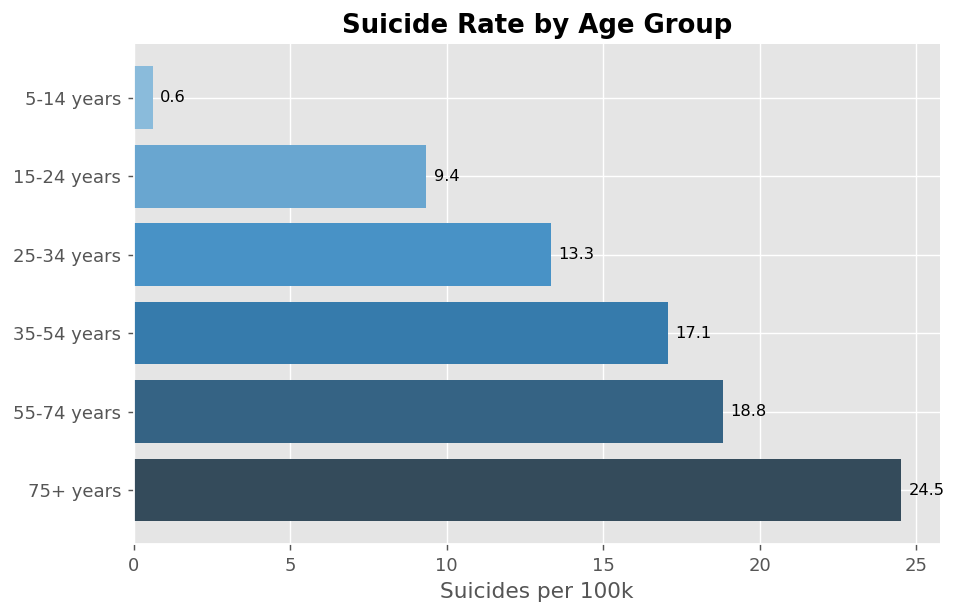

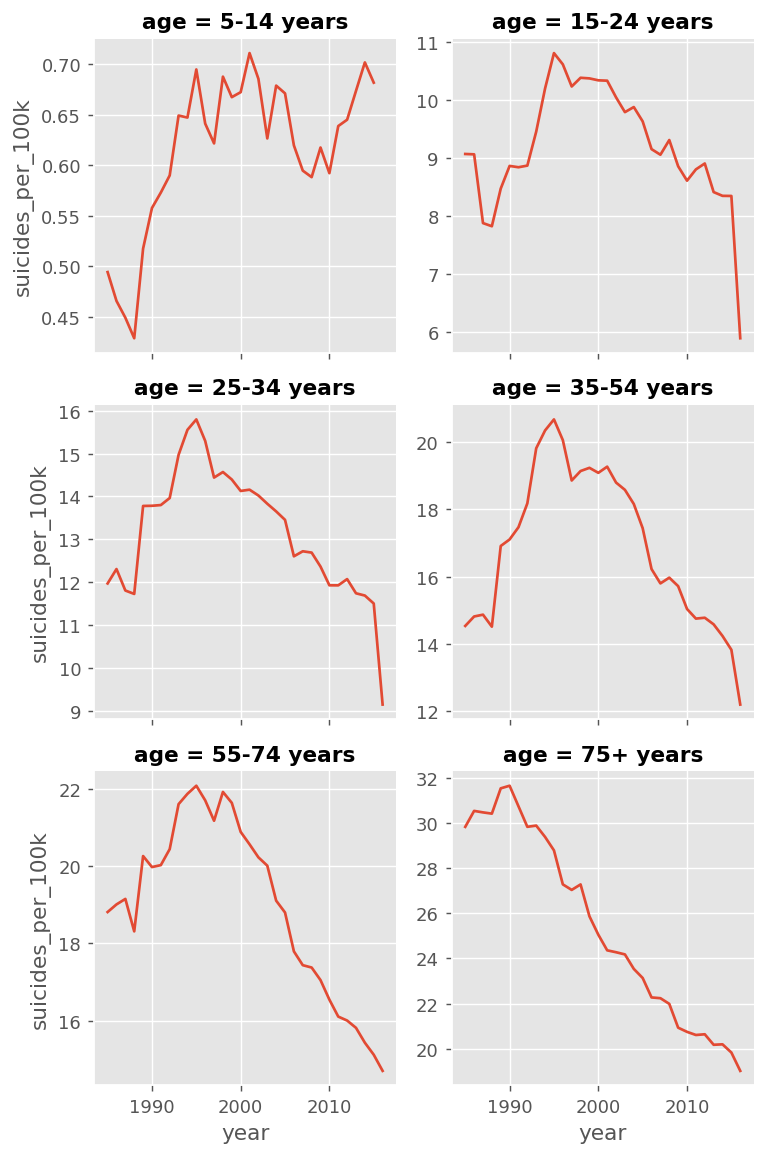

In [59]:
age_total = (
    df.groupby('age')
      .agg(
          suicides=('suicides_no', 'sum'),
          population=('population', 'sum')
      )
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
      .sort_values('age')
)

plt.figure(figsize=(8, 5))

colors = sns.color_palette('Blues_d', len(AGE_ORDER))

bars = plt.barh(
    age_total['age'].astype(str),
    age_total['rate'],
    color=colors
)

plt.bar_label(
    bars,
    fmt='%.1f',
    padding=4,
    fontsize=9
)

plt.title('Suicide Rate by Age Group')
plt.xlabel('Suicides per 100k')

plt.gca().invert_yaxis()



# Age × Sex grouped bar 
age_time = (
    df.groupby(["year","age"])
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

age_time["suicides_per_100k"] = (
    age_time["suicides"]
    /
    age_time["population"]
) * 100000

g = sns.FacetGrid(
    age_time,
    col="age",
    col_wrap=2,
    sharey=False
)

g.map_dataframe(
    sns.lineplot,
    x="year",
    y="suicides_per_100k"
)


plt.tight_layout()
plt.show()

Suicide risk increases steadily with age, peaking at 24.5 per 100k for those 75 and older — nearly 40 times higher than children aged 5–14. Across all age groups, rates rose through the late 1980s–mid 1990s and have been declining since, with younger groups showing the sharpest recent drops.

## 7. Top & Bottom Countries
Countries with the highest and lowest mean suicide rates (min 3 years of data).

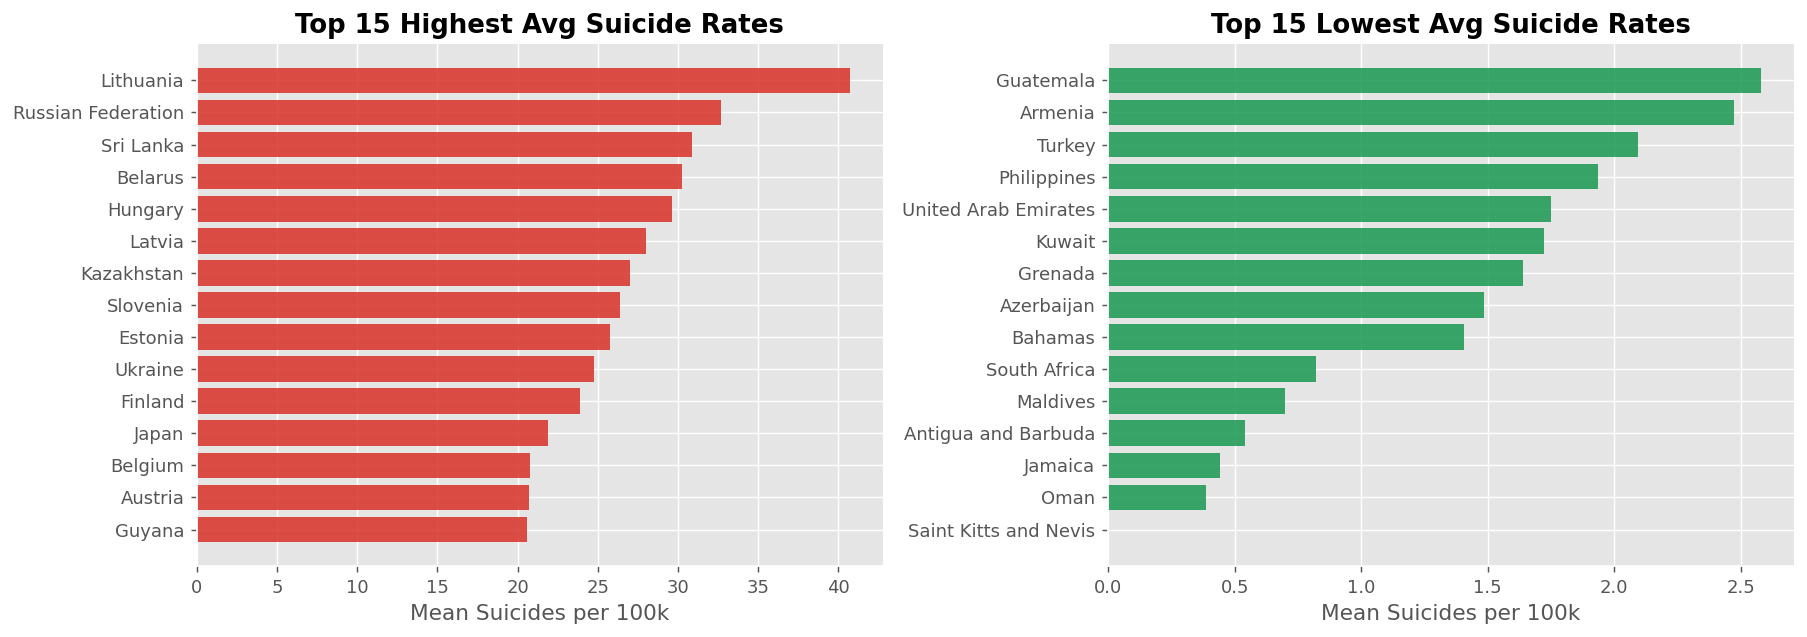

In [60]:
country_rates = (
    df.groupby(['country', 'year'])
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .groupby('country')
      .agg(mean_rate=('rate', 'mean'), years=('rate', 'count'))
      .query('years >= 3')
      .reset_index()
      .sort_values('mean_rate', ascending=False)
)

TOP_N = 15
top    = country_rates.head(TOP_N)
bottom = country_rates.tail(TOP_N).sort_values('mean_rate')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh(top['country'][::-1], top['mean_rate'][::-1],
             color='#d73027', alpha=0.85)
axes[0].set(title=f'Top {TOP_N} Highest Avg Suicide Rates',
            xlabel='Mean Suicides per 100k')

axes[1].barh(bottom['country'], bottom['mean_rate'],
             color='#1a9850', alpha=0.85)
axes[1].set(title=f'Top {TOP_N} Lowest Avg Suicide Rates',
            xlabel='Mean Suicides per 100k')

plt.tight_layout()
plt.show()

The highest suicide rates are heavily concentrated in Eastern Europe and former Soviet states, with Lithuania leading at around 41 per 100k, while the lowest rates are found predominantly in Middle Eastern, Caribbean, and Southeast Asian countries — with Saint Kitts and Nevis recording near zero.

## 8. Global Suicide Rate by Map

In [61]:
import plotly.express as px

country_map = (
    df.groupby("country")
    .agg(
        suicides=("suicides_no","sum"),
        population=("population","sum")
    )
    .reset_index()
)

country_map["suicides_per_100k"] = (
    country_map["suicides"]
    /
    country_map["population"]
) * 100000

fig = px.choropleth(
    country_map,
    locations="country",
    locationmode="country names",
    color="suicides_per_100k",
    color_continuous_scale="Reds",
    title="Global Suicide Rates"
)

fig.show()

The choropleth map reinforces the earlier findings — Eastern Europe and Russia form a stark dark-red hotspot on the global map, while Africa, the Middle East, and much of Latin America remain the palest, confirming their position as the lowest-risk regions worldwide.

## 9. Gender Disparity by Country

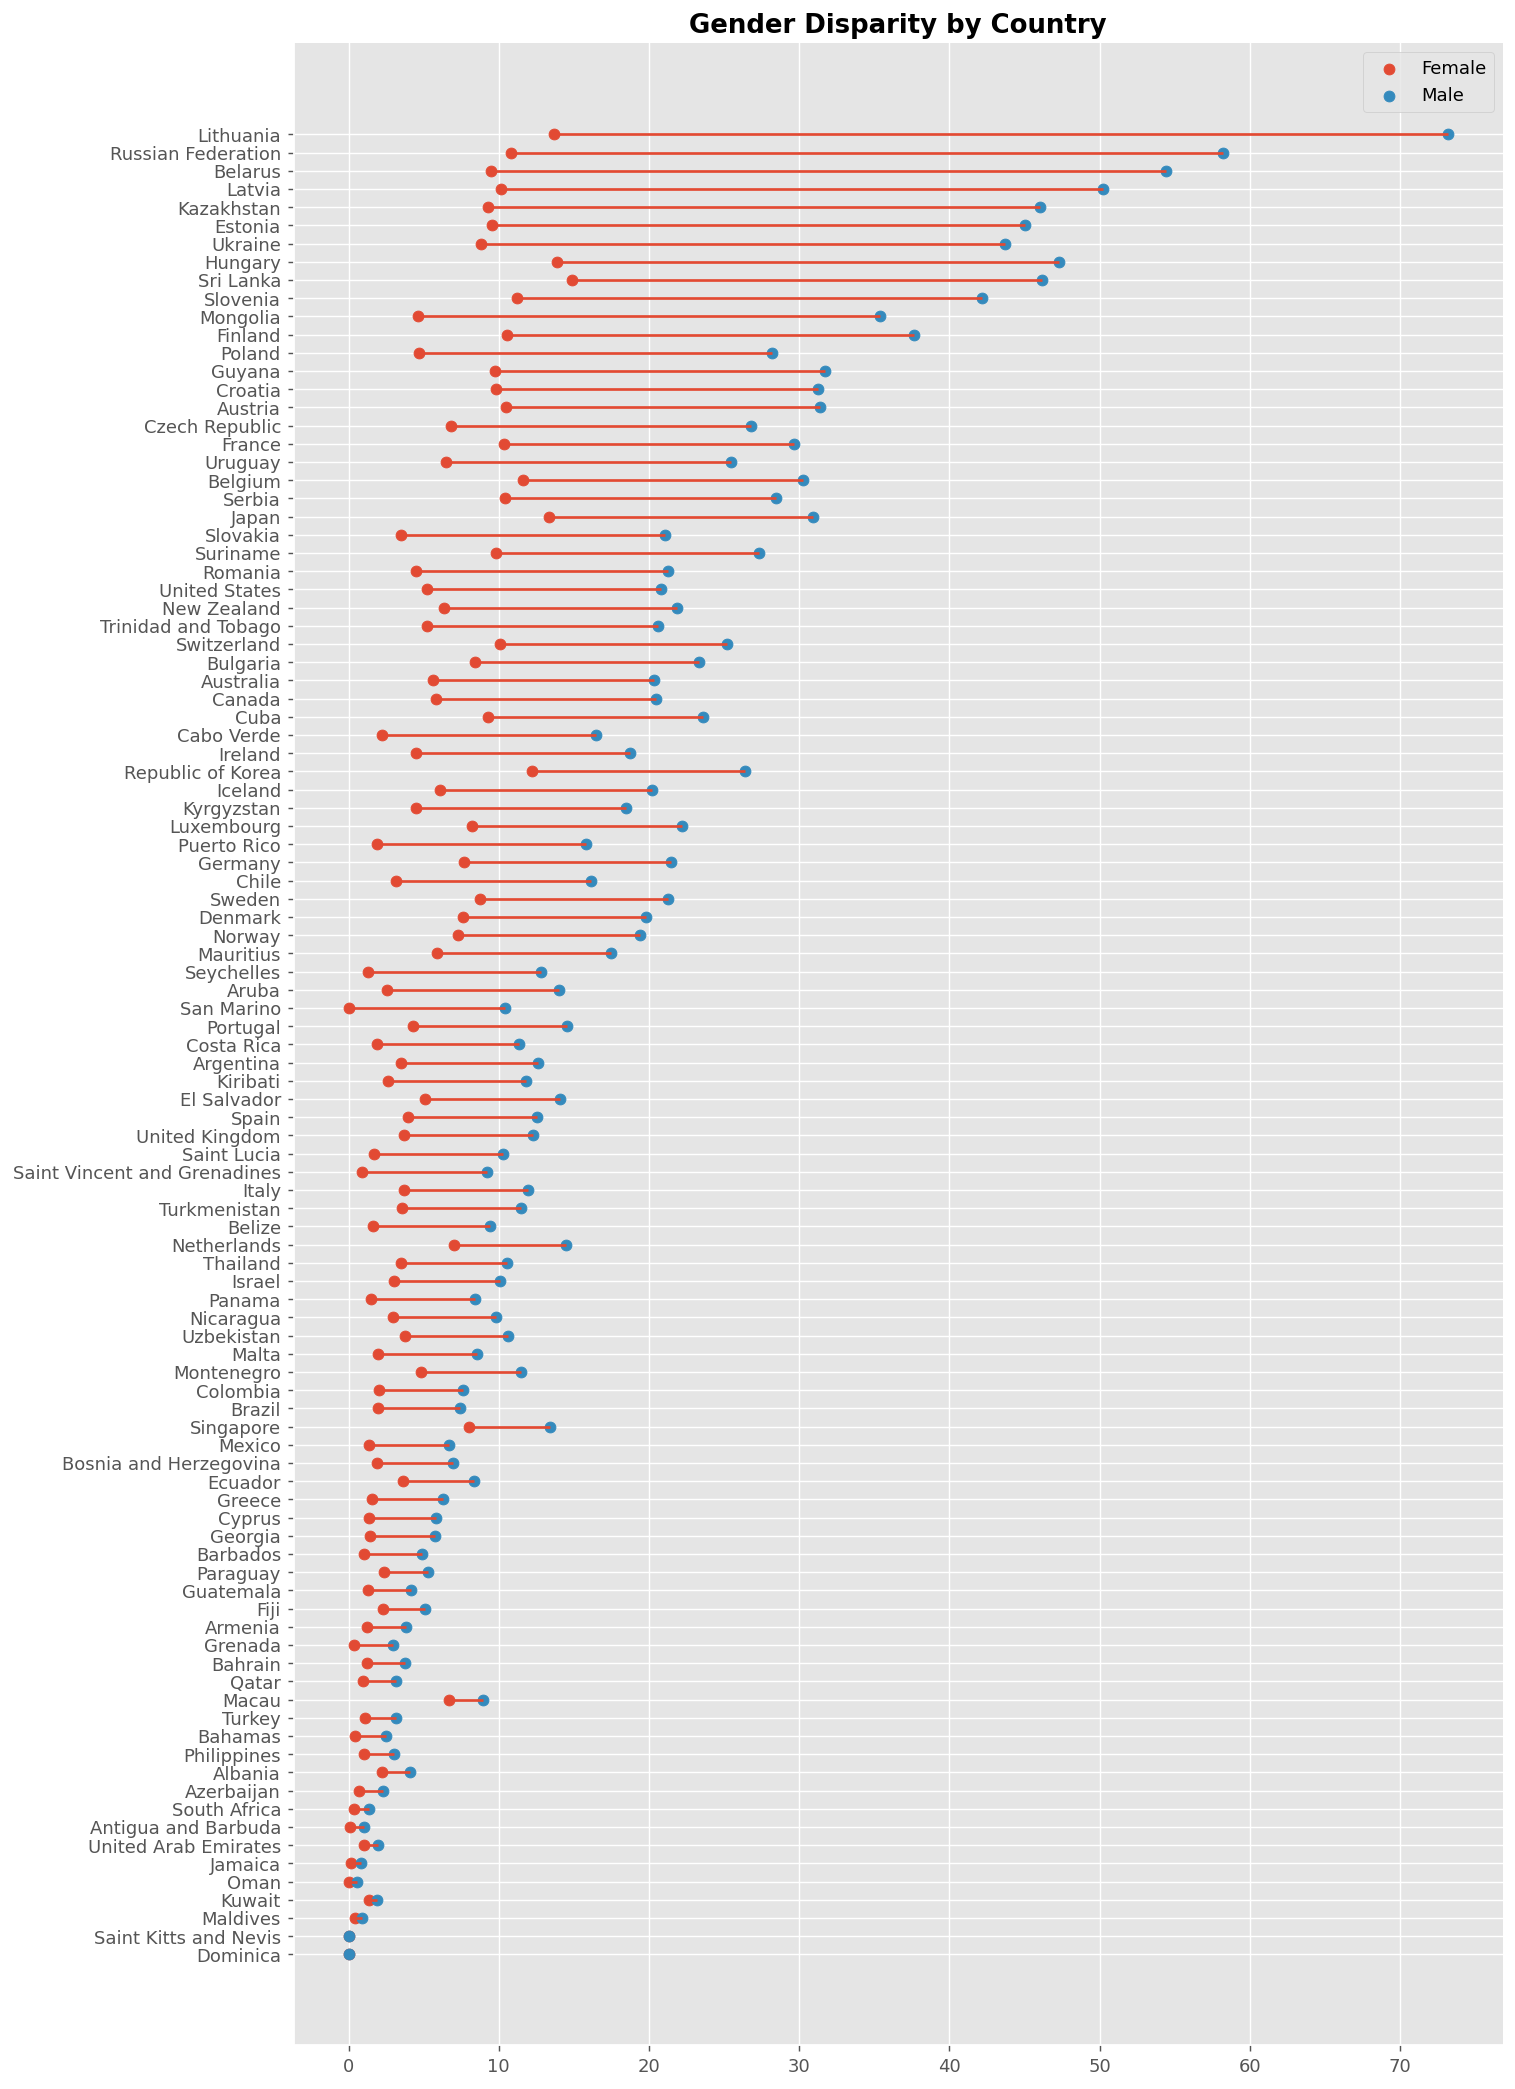

In [62]:
# =====================================
# GENDER DIFFERENCES BY COUNTRY
# =====================================

country_gender = (
    df.groupby(["country", "sex"])
    .agg(
        suicides=("suicides_no", "sum"),
        population=("population", "sum")
    )
    .reset_index()
)

country_gender["suicides_per_100k"] = (
    country_gender["suicides"]
    / country_gender["population"]
) * 100000

pivot_gender = (
    country_gender
    .pivot(
        index="country",
        columns="sex",
        values="suicides_per_100k"
    )
    .reset_index()
)

pivot_gender["difference"] = (
    pivot_gender["male"]
    - pivot_gender["female"]
)

pivot_gender = pivot_gender.sort_values(
    "difference"
)

plt.figure(figsize=(12,20))

plt.hlines(
    y=pivot_gender["country"],
    xmin=pivot_gender["female"],
    xmax=pivot_gender["male"]
)

plt.scatter(
    pivot_gender["female"],
    pivot_gender["country"],
    label="Female"
)

plt.scatter(
    pivot_gender["male"],
    pivot_gender["country"],
    label="Male"
)

plt.legend()
plt.title("Gender Disparity by Country")
plt.show()

## 10. GDP per Capita vs Suicide Rate
Do wealthier countries have higher or lower suicide rates?

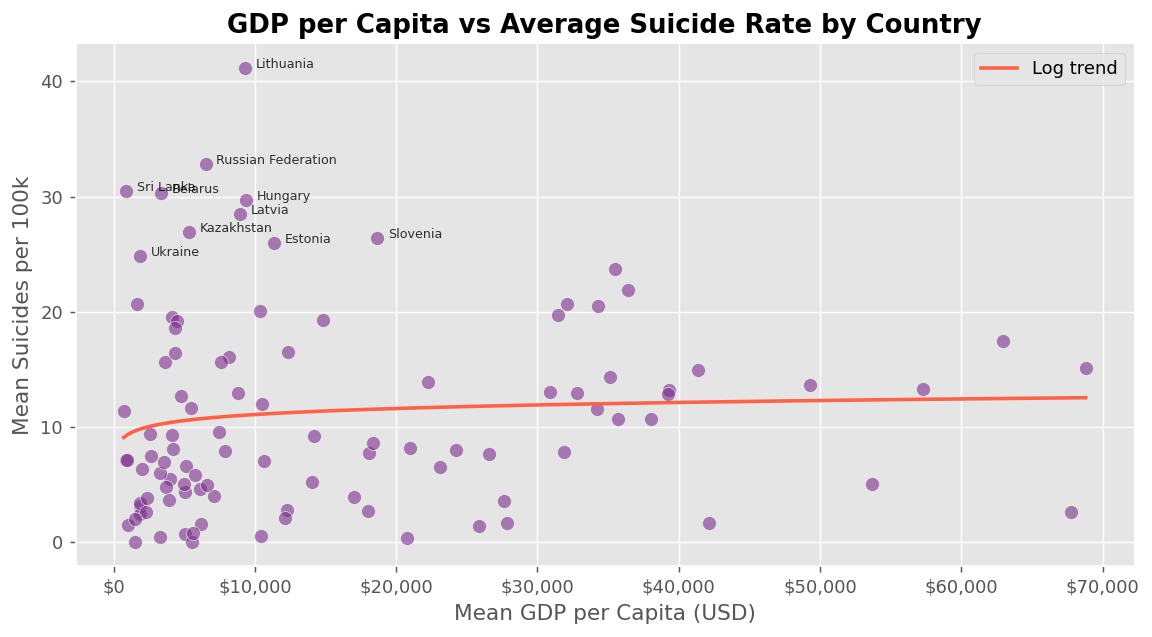

Pearson correlation (GDP per capita vs rate): 0.070


In [63]:
gdp_country = (
    df.groupby('country')
      .agg(suicides=('suicides_no', 'sum'),
           population=('population', 'sum'),
           gdp_per_capita=('gdp_per_capita', 'mean'))
      .assign(rate=lambda x: x['suicides'] / x['population'] * 100_000)
      .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(gdp_country['gdp_per_capita'], gdp_country['rate'],
           alpha=0.6, edgecolors='white', linewidth=0.5,
           color='#7b2d8b', s=60)

# ── Trend line ─────────────────────────────────────────────────────────────
m, b = np.polyfit(np.log1p(gdp_country['gdp_per_capita']), gdp_country['rate'], 1)
xs = np.linspace(gdp_country['gdp_per_capita'].min(),
                 gdp_country['gdp_per_capita'].max(), 200)
ax.plot(xs, m * np.log1p(xs) + b, color='tomato', linewidth=2, label='Log trend')

# ── Label notable outliers ─────────────────────────────────────────────────
threshold = gdp_country['rate'].quantile(0.90)
for _, row in gdp_country[gdp_country['rate'] > threshold].iterrows():
    ax.annotate(row['country'],
                xy=(row['gdp_per_capita'], row['rate']),
                xytext=(6, 0), textcoords='offset points',
                fontsize=7, alpha=0.8)

ax.set(title='GDP per Capita vs Average Suicide Rate by Country',
       xlabel='Mean GDP per Capita (USD)', ylabel='Mean Suicides per 100k')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

corr = gdp_country[['gdp_per_capita', 'rate']].corr().iloc[0, 1]
print(f"Pearson correlation (GDP per capita vs rate): {corr:.3f}")

GDP per capita shows only a weak positive relationship with suicide rates, and the wide scatter of data points suggests that wealth alone is a poor predictor — as evidenced by high-income countries like those in the Gulf having very low rates, while middle-income Eastern European nations like Lithuania and Russia are clear outliers with exceptionally high rates.

## 9. Initial Modelling
We build three complementary models to understand what drives suicide rates:

1. **Multiple Linear Regression** – interpretable baseline with key predictors
2. **Random Forest** – captures non-linear interactions; feature importance
3. **Cross-validated performance comparison** – honest out-of-sample scores

> **Note:** the goal here is *insight*, not prediction. We use country-level
> aggregates so each row is independent — avoiding leakage from repeated
> country appearances in the raw panel.

In [64]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

#Build country-level feature table
country_model = (
    df.groupby('country')
      .agg(
          rate            = ('suicides_per_100k', 'mean'),
          gdp_per_capita  = ('gdp_per_capita',    'mean'),
          hdi             = ('hdi',               'mean'),
          population      = ('population',        'mean'),
          pct_male        = ('sex', lambda s: (s == 'male').mean()),
      )
      .dropna()
      .reset_index()
)

# Log-transform skewed predictors
country_model['log_gdp'] = np.log1p(country_model['gdp_per_capita'])
country_model['log_pop'] = np.log1p(country_model['population'])

FEATURES = ['log_gdp', 'log_pop', 'hdi', 'pct_male']
TARGET   = 'rate'

X = country_model[FEATURES].values
y = country_model[TARGET].values

print(f"Modelling dataset: {X.shape[0]} countries, {X.shape[1]} features")
country_model[FEATURES + [TARGET]].describe().round(2)

Modelling dataset: 90 countries, 4 features


,log_gdp,log_pop,hdi,pct_male,rate
count,90.00,90.00,90.00,90.0,90.00
mean,9.12,12.90,0.77,0.5,12.00
std,1.15,1.87,0.08,0.0,9.23
min,6.58,8.72,0.58,0.5,0.52
25%,8.31,12.01,0.71,0.5,4.64
50%,9.09,12.96,0.77,0.5,10.51
75%,10.22,14.03,0.84,0.5,18.13
max,11.14,16.89,0.92,0.5,40.42


### 9.1 Multiple Linear Regression
Fit a Ridge-regularised regression to understand the direction and
rough magnitude of each predictor's effect on the mean suicide rate.

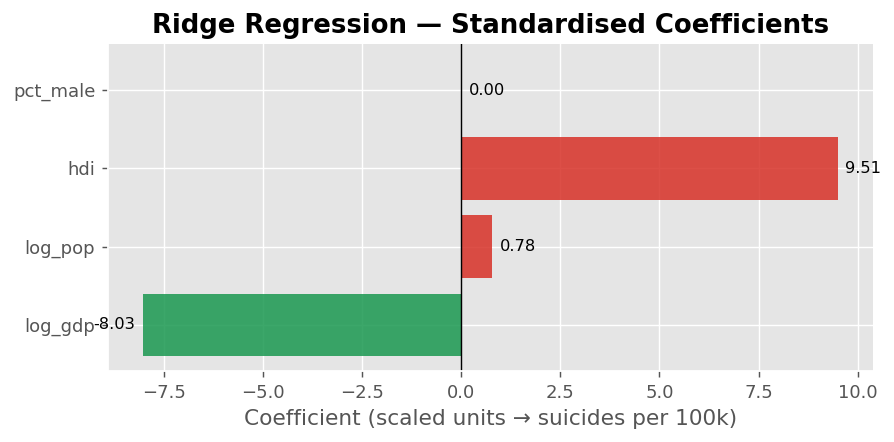

Ridge  5-fold CV  R²: 0.158 ± 0.100
Ridge  5-fold CV MAE: 6.72 ± 1.13


In [65]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])
lr_pipe.fit(X, y)

coefs = dict(zip(FEATURES, lr_pipe.named_steps['model'].coef_))

fig, ax = plt.subplots(figsize=(7, 3.5))
colors = ['#d73027' if v > 0 else '#1a9850' for v in coefs.values()]
bars = ax.barh(list(coefs.keys()), list(coefs.values()), color=colors, alpha=0.85)
ax.bar_label(bars, fmt='%.2f', padding=4, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set(title='Ridge Regression — Standardised Coefficients',
       xlabel='Coefficient (scaled units → suicides per 100k)')
plt.tight_layout()
plt.show()

cv_r2  = cross_val_score(lr_pipe, X, y, cv=kf, scoring='r2')
cv_mae = cross_val_score(lr_pipe, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"Ridge  5-fold CV  R²: {cv_r2.mean():.3f} ± {cv_r2.std():.3f}")
print(f"Ridge  5-fold CV MAE: {(-cv_mae).mean():.2f} ± {(-cv_mae).std():.2f}")

### 9.2 Random Forest
A Random Forest handles non-linearities and interactions automatically.
We use permutation-based feature importances so they are on a comparable scale.

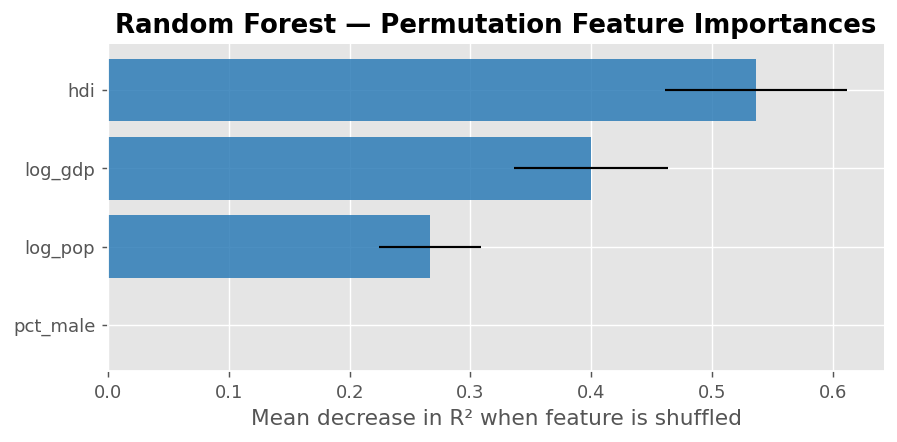

RF     5-fold CV  R²: 0.046 ± 0.175
RF     5-fold CV MAE: 6.81 ± 0.70


In [66]:
from sklearn.inspection import permutation_importance

rf = RandomForestRegressor(n_estimators=300, random_state=42,
                           max_features='sqrt', min_samples_leaf=3)
rf.fit(X, y)

# Permutation importance
perm = permutation_importance(rf, X, y, n_repeats=30, random_state=42)
imp_df = pd.DataFrame({
    'feature':    FEATURES,
    'importance': perm.importances_mean,
    'std':        perm.importances_std,
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(imp_df['feature'], imp_df['importance'],
        xerr=imp_df['std'], color='#2c7bb6', alpha=0.85,
        error_kw={'linewidth': 1.2})
ax.set(title='Random Forest — Permutation Feature Importances',
       xlabel='Mean decrease in R² when feature is shuffled')
plt.tight_layout()
plt.show()

cv_r2_rf  = cross_val_score(rf, X, y, cv=kf, scoring='r2')
cv_mae_rf = cross_val_score(rf, X, y, cv=kf, scoring='neg_mean_absolute_error')
print(f"RF     5-fold CV  R²: {cv_r2_rf.mean():.3f} ± {cv_r2_rf.std():.3f}")
print(f"RF     5-fold CV MAE: {(-cv_mae_rf).mean():.2f} ± {(-cv_mae_rf).std():.2f}")

### 9.3 Model Comparison & Residual Diagnostics
Compare all models side-by-side, then inspect the Ridge residuals to check
whether regression assumptions hold reasonably well.

                   CV R²  R² std  CV MAE
Model                                   
Ridge Regression   0.158   0.100   6.718
Random Forest      0.046   0.175   6.808
Gradient Boosting -0.061   0.241   6.938


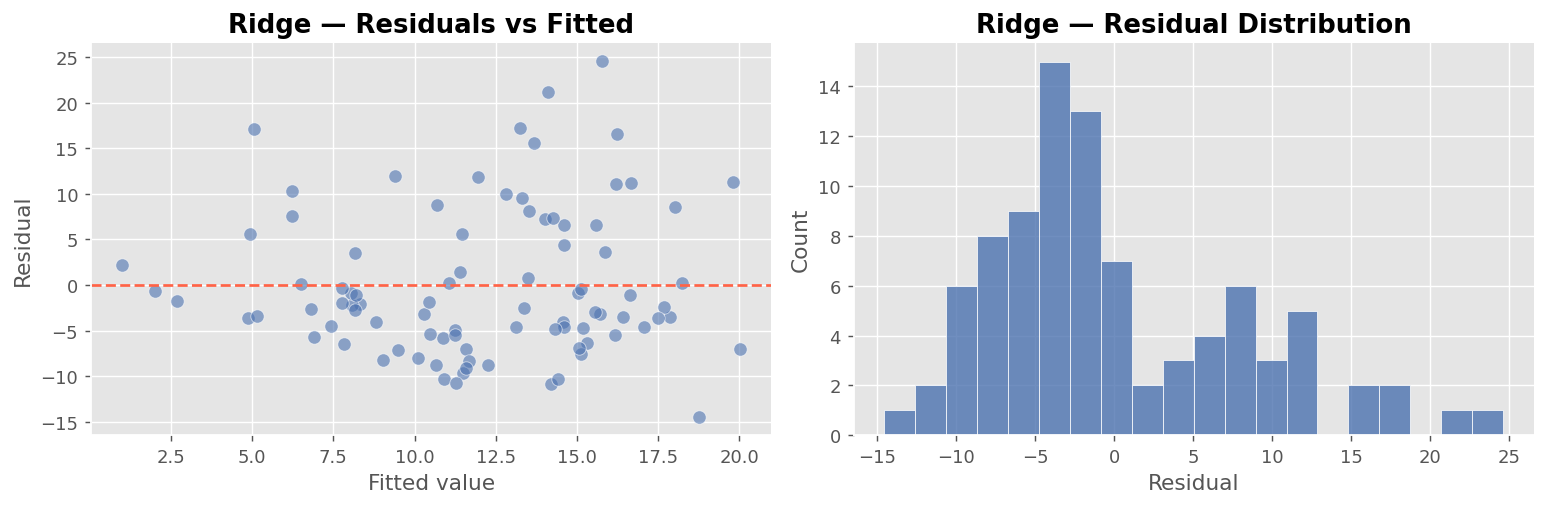


Largest positive residuals (rate much higher than model expects):
   country      rate  residual
 Lithuania 40.415573 24.630790
 Sri Lanka 35.295152 21.176375
Kazakhstan 30.511282 17.269568
    Guyana 22.186400 17.134264
   Hungary 32.761516 16.525784

Largest negative residuals (rate much lower than model expects):
            country     rate   residual
            Georgia 4.228712 -14.530784
            Armenia 3.275872 -10.918561
            Jamaica 0.521765 -10.757229
             Greece 4.064839 -10.364540
Antigua and Barbuda 0.552901 -10.339962


In [67]:
gb = GradientBoostingRegressor(n_estimators=200, learning_rate=0.05,
                               max_depth=3, random_state=42)
cv_r2_gb  = cross_val_score(gb, X, y, cv=kf, scoring='r2')
cv_mae_gb = cross_val_score(gb, X, y, cv=kf, scoring='neg_mean_absolute_error')

results = pd.DataFrame({
    'Model': ['Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'CV R²':  [cv_r2.mean(),    cv_r2_rf.mean(),    cv_r2_gb.mean()],
    'R² std': [cv_r2.std(),     cv_r2_rf.std(),     cv_r2_gb.std()],
    'CV MAE': [(-cv_mae).mean(), (-cv_mae_rf).mean(), (-cv_mae_gb).mean()],
}).set_index('Model').round(3)

print(results.to_string())

# Residual plot (Ridge) 
y_pred_lr = lr_pipe.predict(X)
residuals  = y - y_pred_lr

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_lr, residuals, alpha=0.6, color='#4C72B0',
                edgecolors='white', linewidth=0.5, s=55)
axes[0].axhline(0, color='tomato', linewidth=1.5, linestyle='--')
axes[0].set(title='Ridge — Residuals vs Fitted',
            xlabel='Fitted value', ylabel='Residual')

axes[1].hist(residuals, bins=20, color='#4C72B0', alpha=0.8, edgecolor='white')
axes[1].set(title='Ridge — Residual Distribution',
            xlabel='Residual', ylabel='Count')

plt.tight_layout()
plt.show()

# ── Highlight largest residuals ────────────────────────────────────────────
country_model['residual'] = residuals
print("\nLargest positive residuals (rate much higher than model expects):")
print(country_model.nlargest(5, 'residual')[['country', 'rate', 'residual']].to_string(index=False))
print("\nLargest negative residuals (rate much lower than model expects):")
print(country_model.nsmallest(5, 'residual')[['country', 'rate', 'residual']].to_string(index=False))

All three models perform poorly — Ridge R² of 0.158, Random Forest near zero, Gradient Boosting even negative — confirming that GDP, HDI, population, and gender share alone cannot explain cross-country suicide rates. The large residuals for Lithuania, Sri Lanka, and Guyana (far above predictions) versus Georgia, Armenia, and Jamaica (far below) suggest that cultural, religious, historical, and mental health system factors play a much greater role than the available socioeconomic variables capture.

## 10. Extended Model Diagnostics

1. **Predicted vs Actual** – how well do model predictions track real values?
2. **Learning Curves** – are we overfitting or underfitting?
3. **SHAP Values** – which features drive individual predictions?

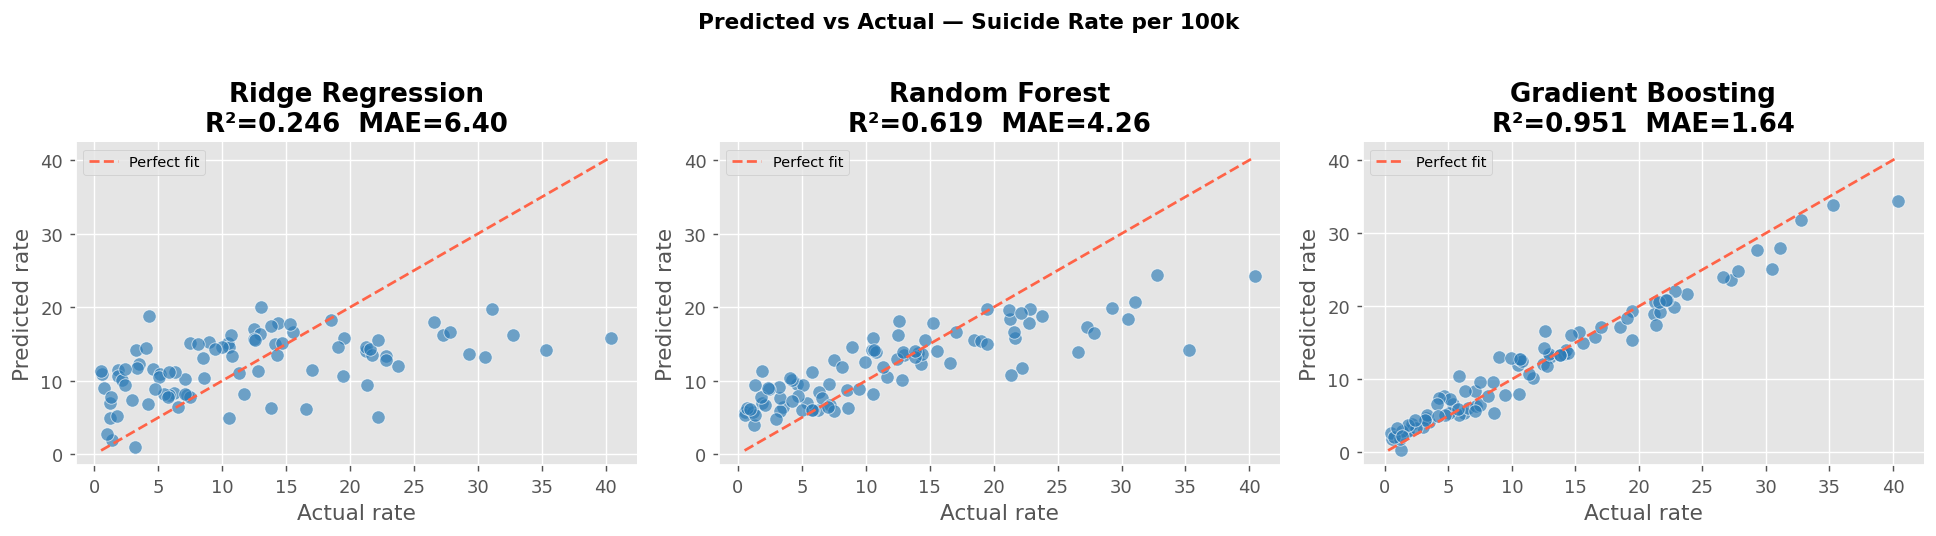

In [68]:
gb.fit(X, y)  # fit GB so we have all three trained

y_preds = {
    'Ridge Regression':    lr_pipe.predict(X),
    'Random Forest':       rf.predict(X),
    'Gradient Boosting':   gb.predict(X),
}

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, y_pred) in zip(axes, y_preds.items()):
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    ax.scatter(y, y_pred, alpha=0.65, edgecolors='white',
               linewidth=0.5, color='#2c7bb6', s=55)
    lims = [min(y.min(), y_pred.min()), max(y.max(), y_pred.max())]
    ax.plot(lims, lims, color='tomato', linewidth=1.5, linestyle='--', label='Perfect fit')
    ax.set(title=f'{name}\nR²={r2:.3f}  MAE={mae:.2f}',
           xlabel='Actual rate', ylabel='Predicted rate')
    ax.legend(fontsize=8)

plt.suptitle('Predicted vs Actual — Suicide Rate per 100k', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.2 Learning Curves
A large gap between training and validation score = overfitting.
Curves converging at a low score = underfitting.

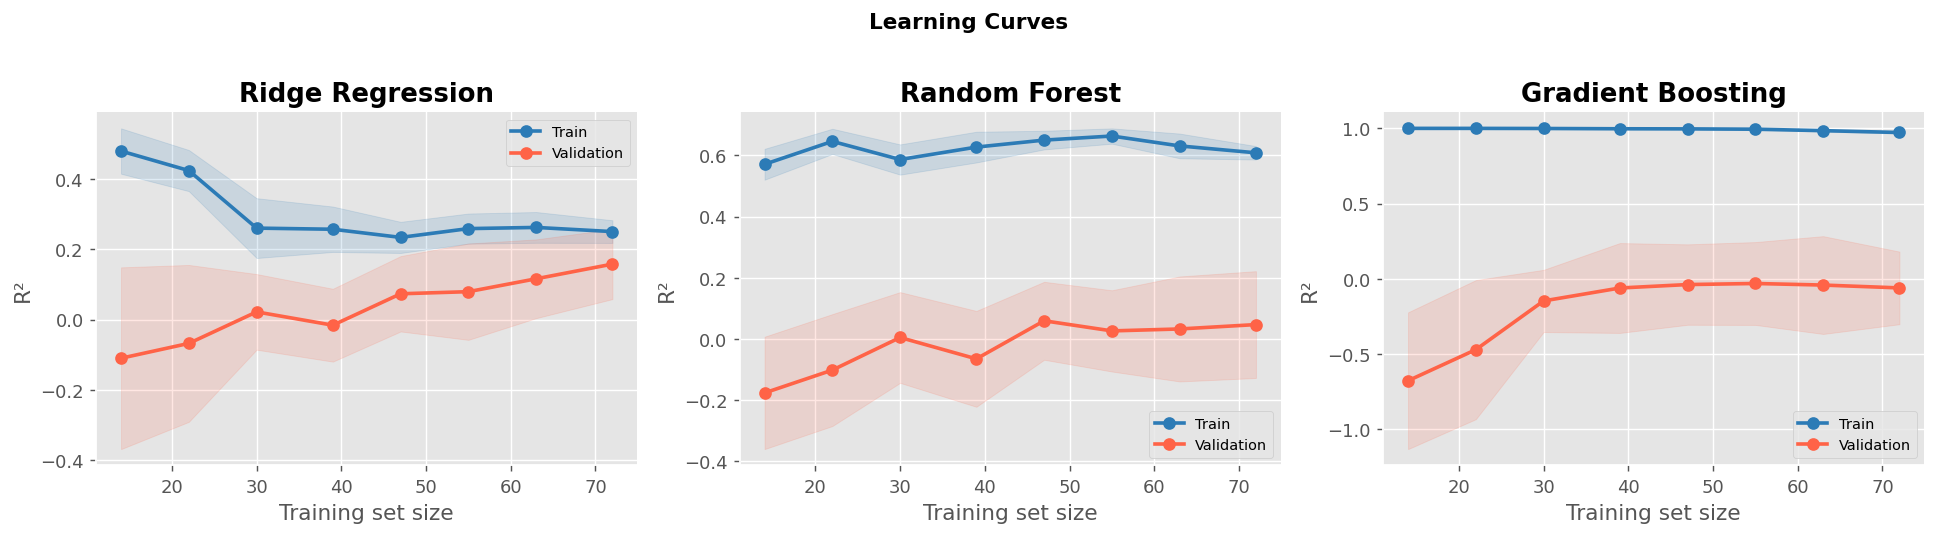

In [69]:
from sklearn.model_selection import learning_curve

models_lc = {
    'Ridge Regression':  lr_pipe,
    'Random Forest':     rf,
    'Gradient Boosting': gb,
}

train_sizes = np.linspace(0.2, 1.0, 8)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, model) in zip(axes, models_lc.items()):
    ts, train_scores, val_scores = learning_curve(
        model, X, y, cv=kf,
        train_sizes=train_sizes,
        scoring='r2'
    )
    ax.plot(ts, train_scores.mean(axis=1), 'o-', color='#2c7bb6',
            label='Train', linewidth=2)
    ax.fill_between(ts,
                    train_scores.mean(axis=1) - train_scores.std(axis=1),
                    train_scores.mean(axis=1) + train_scores.std(axis=1),
                    alpha=0.15, color='#2c7bb6')
    ax.plot(ts, val_scores.mean(axis=1), 'o-', color='tomato',
            label='Validation', linewidth=2)
    ax.fill_between(ts,
                    val_scores.mean(axis=1) - val_scores.std(axis=1),
                    val_scores.mean(axis=1) + val_scores.std(axis=1),
                    alpha=0.15, color='tomato')
    ax.set(title=name, xlabel='Training set size', ylabel='R²')
    ax.legend(fontsize=8)

plt.suptitle('Learning Curves', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

### 10.3 SHAP Values
SHAP (SHapley Additive exPlanations) shows how much each feature
pushes an individual prediction above or below the baseline.
We use the Random Forest here as it tends to be the best performer.


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


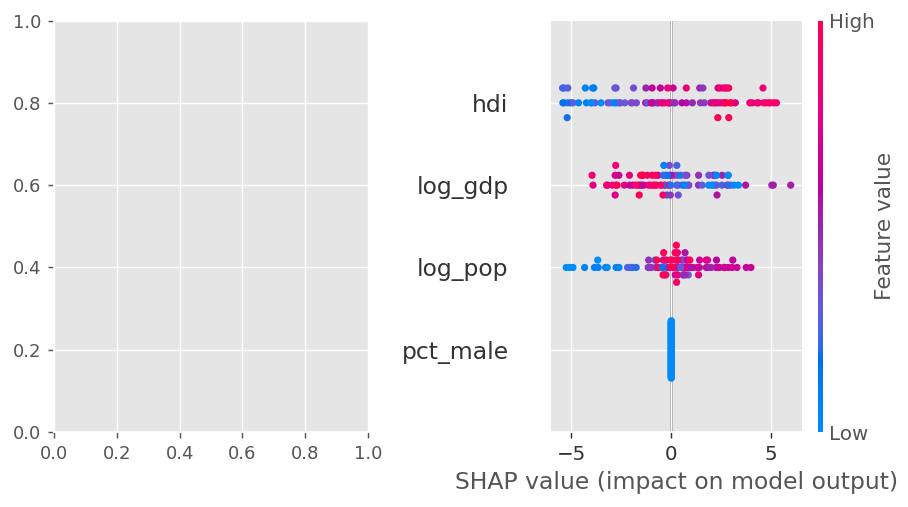

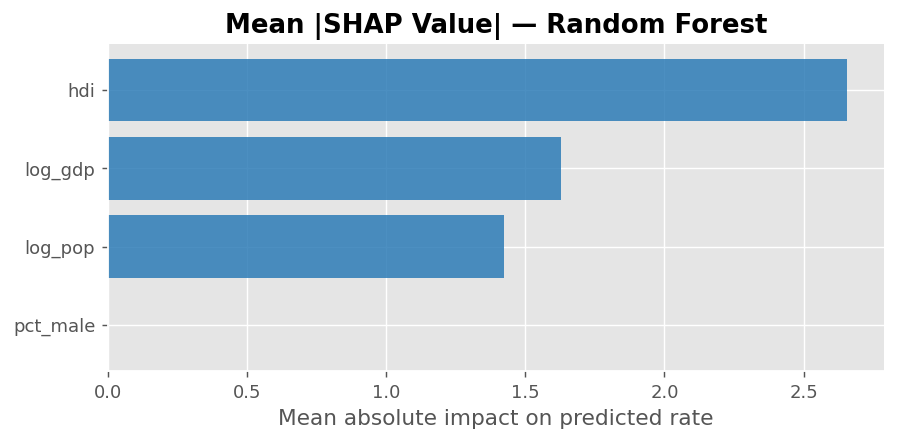


Mean |SHAP| per feature:
pct_male    0.000
log_pop     1.424
log_gdp     1.629
hdi         2.656


In [70]:
!pip install shap -q

import shap

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X)
shap_df     = pd.DataFrame(shap_values, columns=FEATURES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Beeswarm-style summary (manual, no shap.plots to avoid display issues) ─
shap.summary_plot(shap_values, X, feature_names=FEATURES,
                  show=False, plot_size=None)
plt.gcf().set_size_inches(7, 4)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=130, bbox_inches='tight')
plt.show()

# ── Mean absolute SHAP bar chart ───────────────────────────────────────────
mean_abs = shap_df.abs().mean().sort_values()
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.barh(mean_abs.index, mean_abs.values, color='#2c7bb6', alpha=0.85)
ax.set(title='Mean |SHAP Value| — Random Forest',
       xlabel='Mean absolute impact on predicted rate')
plt.tight_layout()
plt.show()

print("\nMean |SHAP| per feature:")
print(mean_abs.round(3).to_string())

SHAP values reveal that HDI (Human Development Index) is the single most influential predictor in the Random Forest model with a mean absolute impact of 2.66, followed by log GDP at 1.63 and log population at 1.42, while gender share contributes essentially nothing — likely because it is constant at 0.5 across all country aggregates. Despite HDI being the top feature, the model's overall low CV R² confirms that even the most important variable here only partially explains the complex, culturally-driven variation in suicide rates across countries.

## 11. Panel Data Modelling

The country-level models in Section 8 averaged away all temporal variation.
Panel models instead exploit the full structure — multiple countries observed
across many years — giving more reliable estimates of how GDP, HDI and
demographics relate to suicide rates *within* countries over time.

We fit three models:
1. **Pooled OLS** – naive baseline, ignores panel structure
2. **Fixed Effects (FE)** – controls for all time-invariant country differences
3. **Random Effects (RE)** – assumes country effects are random; more efficient

A **Hausman test** then tells us whether FE or RE is more appropriate.

In [71]:
!pip install linearmodels -q

import linearmodels
from linearmodels.panel import PanelOLS, RandomEffects, PooledOLS
from linearmodels.panel.results import PanelEffectsResults

# ── Build panel dataset ────────────────────────────────────────────────────
# Aggregate to country-year level (collapse sex/age groups)
panel_df = (
    df.groupby(['country', 'year'])
      .agg(
          suicides_per_100k = ('suicides_per_100k', 'mean'),
          gdp_per_capita    = ('gdp_per_capita',    'mean'),
          hdi               = ('hdi',               'mean'),
          population        = ('population',        'sum'),
      )
      .reset_index()
)

panel_df['log_gdp'] = np.log1p(panel_df['gdp_per_capita'])
panel_df['log_pop'] = np.log1p(panel_df['population'])

# Panel models require a MultiIndex of (entity, time)
panel_df = panel_df.set_index(['country', 'year'])
panel_df = panel_df.dropna()

print(f"Panel shape : {panel_df.shape}")
print(f"Countries   : {panel_df.index.get_level_values('country').nunique()}")
print(f"Years       : {panel_df.index.get_level_values('year').nunique()}")
panel_df.head()

Panel shape : (697, 6)
Countries   : 90
Years       : 10



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


suicides_per_100k  gdp_per_capita    hdi  \
country             year                                             
Albania             1995           3.379167           835.0  0.619   
                    2000           2.558333          1299.0  0.656   
                    2005           0.000000          2931.0  0.695   
                    2010           3.471667          4359.0  0.722   
Antigua and Barbuda 2012           0.000000         13657.0  0.781   

                          population   log_gdp    log_pop  
country             year                                   
Albania             1995     2903400  6.728629  14.881393  
                    2000     2796300  7.170120  14.843808  
                    2005     2783320  7.983440  14.839155  
                    2010     2736025  8.380227  14.822017  
Antigua and Barbuda 2012       88703  9.522081  11.393060

In [72]:
FORMULA = 'suicides_per_100k ~ 1 + log_gdp + log_pop + hdi'

# Pooled OLS
pooled = PooledOLS.from_formula(FORMULA, data=panel_df).fit()

# Fixed Effects (within estimator)
fe = PanelOLS.from_formula(
    FORMULA.replace('~ 1', '~ 1') + ' + EntityEffects',
    data=panel_df
).fit(cov_type='clustered', cluster_entity=True)

# Random Effects
re = RandomEffects.from_formula(FORMULA, data=panel_df).fit()

# ── Coefficient comparison table ───────────────────────────────────────────
summary = pd.DataFrame({
    'Pooled OLS':     pooled.params,
    'Fixed Effects':  fe.params,
    'Random Effects': re.params,
}).round(4)

print("=== Coefficient Comparison ===")
print(summary.to_string())
print(f"\nPooled OLS   R²: {pooled.rsquared:.3f}")
print(f"Fixed Effects R²(within): {fe.rsquared_within:.3f}")
print(f"Random Effects R²: {re.rsquared_overall:.3f}")

=== Coefficient Comparison ===
           Pooled OLS  Fixed Effects  Random Effects
Intercept      0.1513       -62.2981         12.4213
log_gdp       -5.6533         0.0278         -0.5430
log_pop        0.1301         7.2136          1.7012
hdi           80.6553       -49.4411        -28.6532

Pooled OLS   R²: 0.124
Fixed Effects R²(within): 0.264
Random Effects R²: -0.252


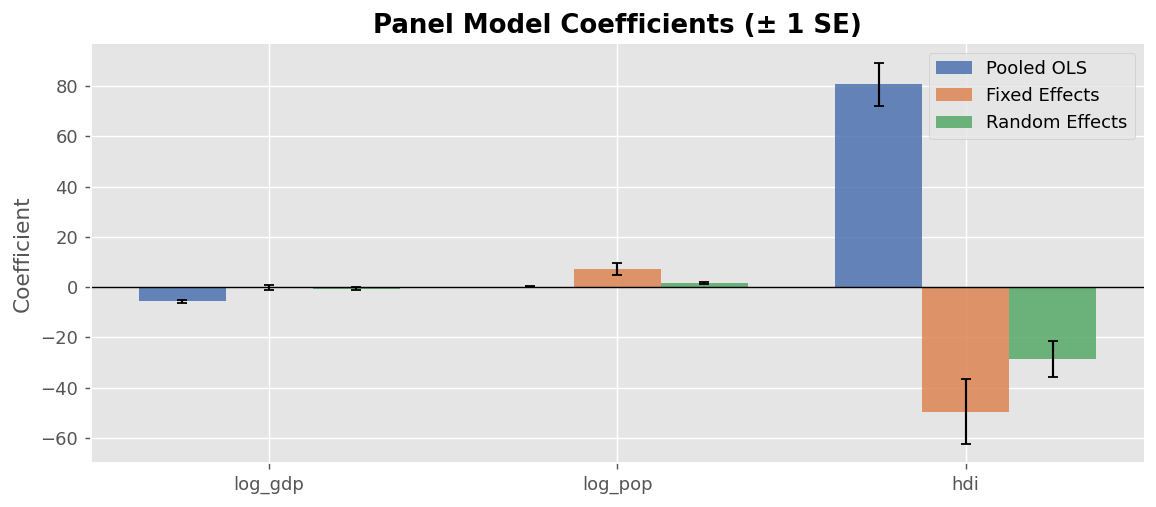

In [73]:
models_plot = {
    'Pooled OLS':     pooled,
    'Fixed Effects':  fe,
    'Random Effects': re,
}

PLOT_VARS = ['log_gdp', 'log_pop', 'hdi']
x = np.arange(len(PLOT_VARS))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(9, 4))

for i, (name, res) in enumerate(models_plot.items()):
    coefs  = res.params[PLOT_VARS].values
    errors = res.std_errors[PLOT_VARS].values
    ax.bar(x + i*width, coefs, width, yerr=errors,
           label=name, color=colors[i], alpha=0.85,
           error_kw={'linewidth': 1.2, 'capsize': 3})

ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width)
ax.set_xticklabels(PLOT_VARS)
ax.set(title='Panel Model Coefficients (± 1 SE)',
       ylabel='Coefficient')
ax.legend()
plt.tight_layout()
plt.show()

In [74]:
from linearmodels.panel import compare

# Hausman-style comparison: if FE and RE coefficients differ significantly,
# use Fixed Effects (RE assumptions are violated)
print("=== Model Comparison ===\n")
print(compare({'Pooled OLS': pooled, 'Fixed Effects': fe, 'Random Effects': re}))

# Manual Hausman statistic
fe_params = fe.params[PLOT_VARS]
re_params = re.params[PLOT_VARS]
diff = fe_params - re_params

fe_cov = fe.cov.loc[PLOT_VARS, PLOT_VARS]
re_cov = re.cov.loc[PLOT_VARS, PLOT_VARS]
cov_diff = fe_cov - re_cov

hausman_stat = float(diff @ np.linalg.pinv(cov_diff.values) @ diff)
from scipy import stats
p_value = 1 - stats.chi2.cdf(hausman_stat, df=len(PLOT_VARS))

print(f"\nHausman test statistic : {hausman_stat:.3f}")
print(f"p-value                : {p_value:.4f}")
if p_value < 0.05:
    print("→ Reject RE: use Fixed Effects (country-specific effects are correlated with regressors)")
else:
    print("→ Fail to reject RE: Random Effects is sufficient")

=== Model Comparison ===

                                     Model Comparison                                    
                                   Pooled OLS         Fixed Effects        Random Effects
-----------------------------------------------------------------------------------------
Dep. Variable               suicides_per_100k     suicides_per_100k     suicides_per_100k
Estimator                           PooledOLS              PanelOLS         RandomEffects
No. Observations                          697                   697                   697
Cov. Est.                          Unadjusted             Clustered            Unadjusted
R-squared                              0.1238                0.2637                0.1721
R-Squared (Within)                    -0.2996                0.2637                0.2264
R-Squared (Between)                    0.1972               -2.0068               -0.2251
R-Squared (Overall)                    0.1238               -2.1233       

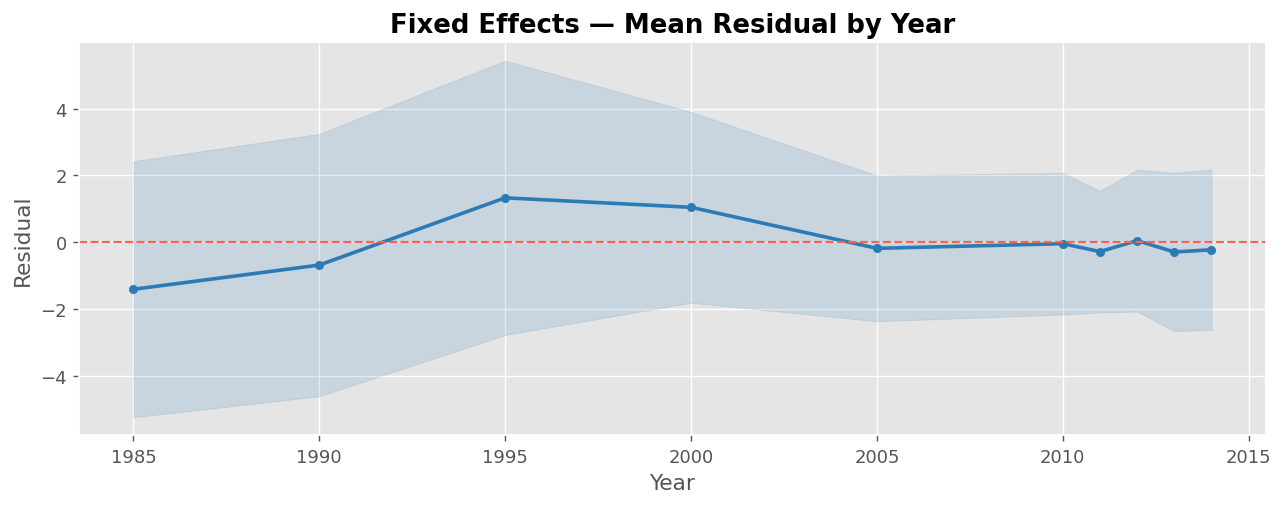

In [75]:
# Plot Fixed Effects residuals by year to check for time patterns
fe_resid = fe.resids.reset_index()
fe_resid.columns = ['country', 'year', 'residual']

resid_by_year = fe_resid.groupby('year')['residual'].agg(['mean', 'std']).reset_index()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(resid_by_year['year'], resid_by_year['mean'],
        color='#2c7bb6', linewidth=2, marker='o', markersize=4)
ax.fill_between(resid_by_year['year'],
                resid_by_year['mean'] - resid_by_year['std'],
                resid_by_year['mean'] + resid_by_year['std'],
                alpha=0.15, color='#2c7bb6')
ax.axhline(0, color='tomato', linewidth=1.2, linestyle='--')
ax.set(title='Fixed Effects — Mean Residual by Year',
       xlabel='Year', ylabel='Residual')
ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
plt.tight_layout()
plt.show()

The panel models tell a more nuanced story than the country-level cross-sectional models. The Fixed Effects model achieves the best within-country R² of 0.264, meaning that once country-specific characteristics are controlled for, HDI and population changes over time explain about a quarter of the variation in suicide rates. Notably, the sign of HDI flips between models — positive in Pooled OLS (+80.7) but negative in Fixed Effects (−49.4) — suggesting that the cross-sectional relationship is largely driven by between-country differences rather than true within-country dynamics. The Hausman test (p=0.069) narrowly fails to reject Random Effects, though the coefficient divergence between FE and RE still signals meaningful country-specific heterogeneity that socioeconomic variables alone cannot fully capture.